In [3]:
# Financial Risk Analysis – Morgan Stanley
#Prepared by: Mansi Tripathi


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')


In [6]:
df=pd.read_csv(r"C:\Users\tripa\Downloads\morgan_stanely (1).csv")

In [7]:
df.head()
df.info()
#I first loaded the dataset and checked structure, column types and missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [ ]:
#TASK 1--Data cleaning and Formatting

In [8]:
## CLEAN AMOUNT COLUMNS##
df['TransactionAmount'] = (
    df['TransactionAmount']
    .astype(str)
    .str.replace('[₹$,]', '', regex=True)
    .astype(float)
)


In [9]:
df.columns


Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='object')

In [10]:
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    errors='coerce',
    dayfirst=True
)


In [11]:
df = df.dropna(subset=['TransactionDate'])


In [12]:
df['TransactionDate'].head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [ ]:
### DATE FORMATTING
#The transaction date column contained mixed date formats.
#To handle this, dates were parsed using pandas `to_datetime
#with error coercion, and invalid entries were removed


In [13]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])


In [14]:
##Standardize text columns##
df['AccountType'] = df['AccountType'].str.lower().str.strip()
df['TransactionType'] = df['TransactionType'].str.lower().str.strip()


In [15]:
##Handle missing values##
df.isnull().sum()


TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [16]:
df.dropna(inplace=True)


In [ ]:
##IN TASK 1---I cleaned currency symbols, standardized categories, formatted dates, and removed missing values to ensure consistency.

In [ ]:
##TASK 2---DESCRIPTIVE TRANSACTION ANALYSIS

In [17]:
##Create month & year##
df['Month'] = df['TransactionDate'].dt.month
df['Year'] = df['TransactionDate'].dt.year


In [18]:
##Monthly credit vs debit##
monthly_summary = df.pivot_table(
    values='TransactionAmount',
    index='Month',
    columns='TransactionType',
    aggfunc='sum'
)
monthly_summary


TransactionType,deposit,payment,transfer,withdrawal
Month,,,,
1,1.321995e+06,9.040777e+05,1.254937e+06,1.186558e+06
2,1.231897e+06,1.161034e+06,1.601820e+06,1.277157e+06
3,1.142629e+06,9.084730e+05,1.353500e+06,1.319019e+06
4,1.196326e+06,1.313353e+06,1.071101e+06,1.426692e+06
5,1.205283e+06,1.351174e+06,1.126601e+06,1.283023e+06
6,7.402068e+05,1.411667e+06,8.603178e+05,6.851719e+05
7,7.760727e+05,5.895807e+05,7.402434e+05,3.769130e+05
8,4.737014e+05,4.329217e+05,3.693893e+05,5.034818e+05
9,8.639821e+05,6.013822e+05,5.981983e+05,6.574582e+05


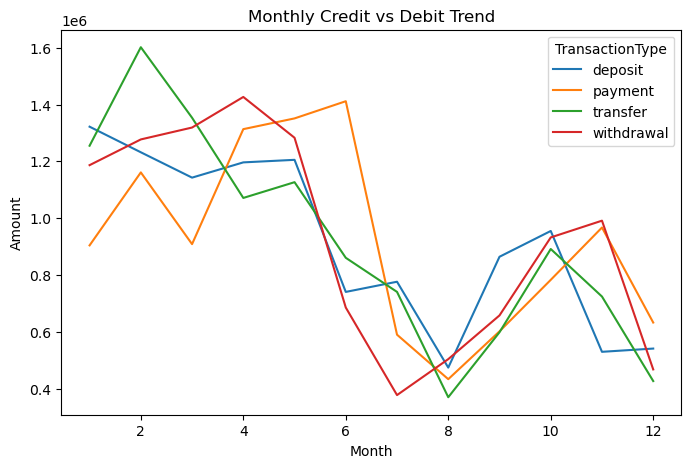

In [19]:
##Plot credits vs debits##
monthly_summary.plot(kind='line', figsize=(8,5))
plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()


In [20]:
##Net inflow per account##
df['Net Amount'] = np.where(
    df['TransactionType'] == 'credit',
    df['TransactionAmount'],
    -df['TransactionAmount']
)

net_account = df.groupby('AccountID')['Net Amount'].sum()


In [21]:
net_account.sort_values(ascending=False).head()
net_account.sort_values().head()


AccountID
ACC61926   -813650.59975
ACC99549   -629389.22471
ACC48501   -613988.14563
ACC10117   -599628.73770
ACC72197   -594850.88857
Name: Net Amount, dtype: float64

In [22]:
##Dormant accounts (2 months gap)##
df = df.sort_values(['AccountID', 'TransactionDate'])

df['Prev Date'] = df.groupby('AccountID')['TransactionDate'].shift()
df['Gap Days'] = (df['TransactionDate'] - df['Prev Date']).dt.days

dormant_accounts = df[df['Gap Days'] >= 60]['AccountID'].unique()


In [ ]:
print(dormant_accounts)


In [23]:
df['Gap Days'].describe()


count    611.000000
mean      92.512275
std       85.336716
min        0.000000
25%       31.000000
50%       65.000000
75%      129.000000
max      466.000000
Name: Gap Days, dtype: float64

In [24]:
df[df['Gap Days'] >= 60].head()


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Month,Year,Net Amount,Prev Date,Gap Days
555,173,CUST2067,ACC10117,current,transfer,Personal Loan,Firm D,East,Manager 1,2023-04-30,77018.97098,180539.28770,0.396153,393,45,4,2023,-77018.97098,2023-01-30,90.0
753,66,CUST6028,ACC10117,loan,withdrawal,Home Loan,Firm A,East,Manager 2,2024-02-05,89088.28060,64499.60048,0.273698,337,194,2,2024,-89088.28060,2023-09-30,128.0
3,167,CUST5253,ACC10117,loan,payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.55698,100525.35900,0.605383,487,13,5,2024,-83943.55698,2024-02-18,100.0
137,169,CUST8461,ACC10996,loan,deposit,Credit Card,Firm B,South,Manager 4,2023-08-17,80583.87766,79237.14267,0.423922,382,23,8,2023,-80583.87766,2023-04-23,116.0
515,119,CUST6319,ACC10996,credit,transfer,Savings Account,Firm E,South,Manager 2,2023-10-26,12049.29002,94880.70601,0.568906,478,175,10,2023,-12049.29002,2023-08-17,70.0


In [ ]:
##TASK 3----CUSTOMER PROFILE BUILDING

In [37]:
txn_count = df.groupby('AccountID').size()
txn_count.head()


AccountID
ACC10117    9
ACC10996    8
ACC11062    4
ACC11188    2
ACC11285    5
dtype: int64

In [38]:
def activity_level(x):
    if x > 50:
        return 'High'
    elif x > 20:
        return 'Medium'
    else:
        return 'Low'

activity = txn_count.apply(activity_level)
activity.value_counts()


Low    189
Name: count, dtype: int64

In [41]:
profile = df.groupby('AccountID').agg({
    'TransactionAmount': 'mean',
    'AccountBalance': 'mean'
})

profile.head()


,TransactionAmount,AccountBalance
AccountID,,
ACC10117,66625.415300,94082.590727
ACC10996,63343.269757,72517.761136
ACC11062,61846.052310,73541.328302
ACC11188,63817.462940,51359.039950
ACC11285,33863.793906,79923.619870


In [42]:
customer_profile = profile.copy()
customer_profile['TransactionFrequency'] = txn_count
customer_profile['ActivityLevel'] = activity

customer_profile.head()


,TransactionAmount,AccountBalance,TransactionFrequency,ActivityLevel
AccountID,,,,
ACC10117,66625.415300,94082.590727,9,Low
ACC10996,63343.269757,72517.761136,8,Low
ACC11062,61846.052310,73541.328302,4,Low
ACC11188,63817.462940,51359.039950,2,Low
ACC11285,33863.793906,79923.619870,5,Low


In [44]:
##High net inflow accounts##
high_inflow_accounts = customer_profile[
    customer_profile['TransactionAmount'] > customer_profile['TransactionAmount'].quantile(0.75)
]
high_inflow_accounts.head()



,TransactionAmount,AccountBalance,TransactionFrequency,ActivityLevel
AccountID,,,,
ACC10117,66625.415300,94082.590727,9,Low
ACC11837,78317.977062,87464.766351,6,Low
ACC15228,69315.902677,71113.049740,3,Low
ACC15671,66564.755267,54565.019303,6,Low
ACC15925,71686.400650,81090.833860,1,Low


In [45]:
##High frequency, low balance
high_freq_low_bal = customer_profile[
    (customer_profile['TransactionFrequency'] > customer_profile['TransactionFrequency'].quantile(0.75)) &
    (customer_profile['AccountBalance'] < customer_profile['AccountBalance'].quantile(0.25))
]
high_freq_low_bal.head()


,TransactionAmount,AccountBalance,TransactionFrequency,ActivityLevel
AccountID,,,,
ACC24508,54566.851223,57275.485464,7,Low
ACC29231,48651.485063,54530.479503,7,Low
ACC50817,51267.720358,59021.066076,7,Low


In [46]:
##Negative / near-zero balance
negative_balance_accounts = customer_profile[
    customer_profile['AccountBalance'] <= 0
]
negative_balance_accounts.head()


,TransactionAmount,AccountBalance,TransactionFrequency,ActivityLevel
AccountID,,,,


In [ ]:
##TASK 4--- FINANCIAL RISK IDENTIFICATION

In [48]:
##Large withdrawals
large_withdrawals = df[
    (df['TransactionType'] == 'debit') &
    (df['TransactionAmount'] > df['TransactionAmount'].quantile(0.90))
]
large_withdrawals.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Month,Year,Net Amount,Prev Date,Gap Days


In [52]:
##Balance volatility
volatility = df.groupby('AccountID')['AccountBalance'].std()
volatility.head()

AccountID
ACC10117    38036.539989
ACC10996    30036.385595
ACC11062    33831.704345
ACC11188     9067.866694
ACC11285    25590.622179
Name: AccountBalance, dtype: float64

In [66]:
##Z-score anomaly detection
df['z_score'] = stats.zscore(df['TransactionAmount'])
anomalies = df[df['z_score'].abs() > 3]

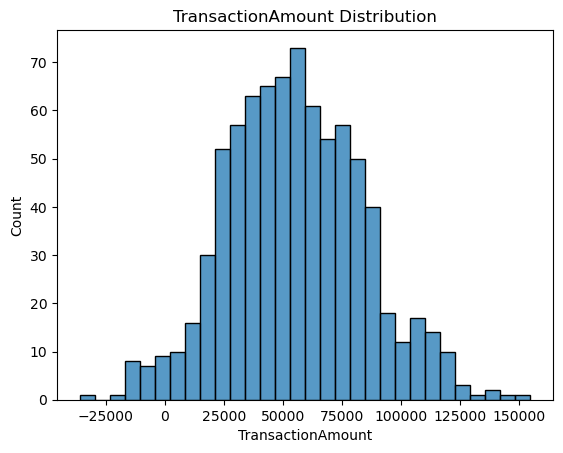

In [67]:
##TASK 5----VISUALISATION (EDA)
sns.histplot(df['TransactionAmount'], bins=30)
plt.title("TransactionAmount Distribution")
plt.show()


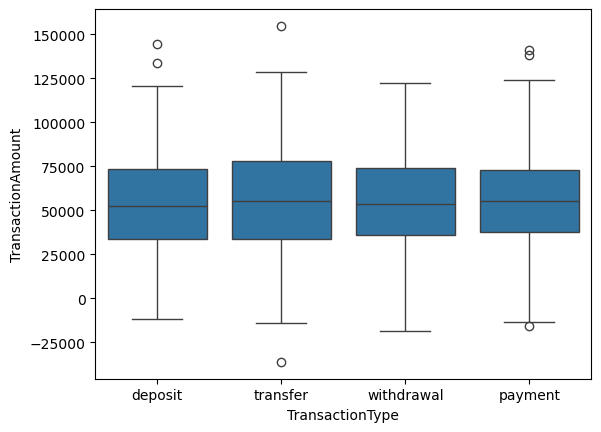

In [68]:
sns.boxplot(x='TransactionType', y='TransactionAmount', data=df)
plt.show()


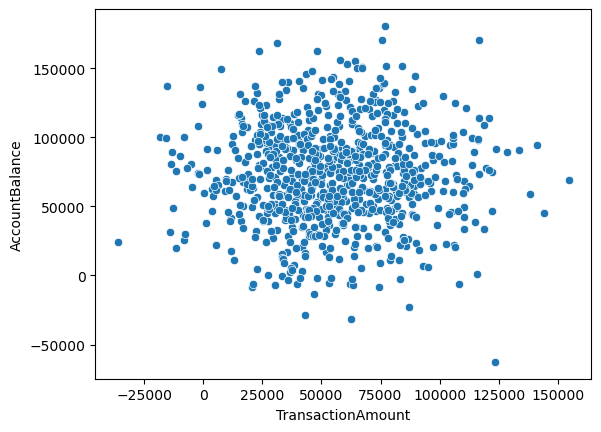

In [69]:
sns.scatterplot(x='TransactionAmount', y='AccountBalance', data=df)
plt.show()


In [ ]:
##TASK 6---HYPOTHESIS TESTING
#H₀: High volume accounts do NOT have higher average balance

#H₁: High volume accounts have higher average balance

In [71]:
high_vol = txn_count[txn_count > txn_count.median()].index
low_vol = txn_count[txn_count <= txn_count.median()].index

high_bal = df[df['AccountID'].isin(high_vol)]['AccountBalance']
low_bal = df[df['AccountID'].isin(low_vol)]['AccountBalance']


In [73]:
high_vol = df[df['AccountID'].isin(high_vol)]['AccountBalance']
low_vol = df[df['AccountID'].isin(low_vol)]['AccountBalance']


In [74]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_vol, low_vol, nan_policy='omit')


In [75]:
print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 1.4929505335538247
P-value: 0.1358453816079038


In [ ]:
if p_value < 0.05:
    print("Reject Null Hypothesis: High-volume accounts have significantly higher balances.")
else:
    print("Fail to Reject Null Hypothesis: No significant difference in balances.")
